In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pes2ug23cs065/hybrid-demand-forecasting/calendar.csv
/kaggle/input/datasets/pes2ug23cs065/hybrid-demand-forecasting/sell_prices.csv
/kaggle/input/datasets/pes2ug23cs065/hybrid-demand-forecasting/sales_train_validation.csv


In [ ]:
import sqlite3
import warnings
import numpy as np
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import norm
from pathlib import Path
 
warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None
print("Imports OK")
 

 
SALES_PATH    = "../../../../data/raw/sales_history.csv"
CALENDAR_PATH = "../../../../data/raw/calendar.csv"
PRICES_PATH   = "data/sell_prices.csv"

OUTPUT_DIR = "."
DB_PATH    = f"{OUTPUT_DIR}/forecast.db"
CSV_PATH   = f"{OUTPUT_DIR}/forecasts.csv"

FORECAST_DAYS = 28
LEAD_TIME     = 7       # days — configurable per warehouse
N_SAMPLE_SKUS = 500     # set None for full 30K (needs 32+ GB)
VAL_WINDOW    = 28      # validation days for metric eval
 
# Service levels → z-scores for safety stock
SL_MAP = {"FOODS": 0.95, "HOUSEHOLD": 0.92, "HOBBIES": 0.90}
 
# Ensemble weights (calibrated on M5 leaderboard patterns)
LGBM_WEIGHT  = 0.60
XGB_WEIGHT   = 0.40
 
print(" Config ready")
 
 

✅ Imports OK
✅ Config ready


In [3]:
 
# ── CELL 3: MEMORY HELPERS ─────────────────────────────────────
 
import gc
def reduce_mem(df: pd.DataFrame) -> pd.DataFrame:
    """Downcast all numeric columns to the smallest safe type."""
    for col in df.select_dtypes(include=["int64", "int32"]).columns:
        df[col] = pd.to_numeric(df[col], downcast="integer")
    for col in df.select_dtypes(include=["float64"]).columns:
        df[col] = df[col].astype(np.float32)
    return df
 
 
def mem_report(df: pd.DataFrame, label: str = ""):
    mb = df.memory_usage(deep=True).sum() / 1e6
    print(f"  [{label}] shape={df.shape}  mem={mb:.1f} MB")
 
 
def flush(*args):
    """Delete objects and run GC."""
    for a in args:
        del a
    gc.collect()
 
 
print("✅ Memory helpers ready")
 
 
# ── CELL 4: LOAD SALES (wide → long) ──────────────────────────
 
print("Loading sales data...")
sales_dtypes = {
    "id": "category", "item_id": "category", "dept_id": "category",
    "cat_id": "category", "store_id": "category", "state_id": "category",
}
sales = pd.read_csv(SALES_PATH, dtype=sales_dtypes)
 
if N_SAMPLE_SKUS:
    # Stratified sample: keep variety across store × category
    sales = (
        sales
        .groupby(["store_id", "cat_id"], observed=True)
        .apply(lambda g: g.sample(
            min(len(g), max(1, N_SAMPLE_SKUS // 30)), random_state=42
        ))
        .reset_index(drop=True)
    )
    print(f"  Sampled → {len(sales):,} SKUs")
 
id_cols  = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
day_cols = [c for c in sales.columns if c.startswith("d_")]
sales    = sales.melt(
    id_vars=id_cols, value_vars=day_cols,
    var_name="d", value_name="sales"
)
sales["sales"] = sales["sales"].astype(np.int16)
mem_report(sales, "sales long")
gc.collect()

✅ Memory helpers ready
Loading sales data...
  Sampled → 480 SKUs
  [sales long] shape=(918240, 8)  mem=62.8 MB


0

In [4]:
# ── CELL 5: LOAD CALENDAR & PRICES ────────────────────────────
 
print("Loading calendar...")
cal = pd.read_csv(CALENDAR_PATH, parse_dates=["date"])
cal["d"]          = cal["d"].astype("category")
cal["event_flag"] = cal["event_name_1"].notna().astype(np.int8)
cal["event_type"] = cal["event_type_1"].fillna("none").astype("category")
cal["snap_CA"]    = cal["snap_CA"].astype(np.int8)
cal["snap_TX"]    = cal["snap_TX"].astype(np.int8)
cal["snap_WI"]    = cal["snap_WI"].astype(np.int8)
cal = cal[["d", "date", "wm_yr_wk", "weekday", "wday", "month", "year",
           "event_flag", "event_type", "snap_CA", "snap_TX", "snap_WI"]]
cal = reduce_mem(cal)
 
print("Loading prices...")
prices = pd.read_csv(
    PRICES_PATH,
    dtype={"store_id": "category", "item_id": "category"}
)
prices["sell_price"] = prices["sell_price"].astype(np.float32)
mem_report(prices, "prices")
 
 
# ── CELL 6: MERGE & PREPROCESS ────────────────────────────────
 
print("Merging datasets...")
df = sales.merge(cal, on="d", how="left")
df = df.merge(prices, on=["store_id", "item_id", "wm_yr_wk"], how="left")
flush(sales, cal, prices)
 
df = df.sort_values(["id", "date"]).reset_index(drop=True)
 
# ---- Stockout detection ----
# Price = NaN → item not listed that week → mark as censored
df["on_shelf"] = df["sell_price"].notna().astype(np.int8)
 
# Detect probable stockouts: price present, demand=0 for 7+ consecutive days
def flag_stockouts(grp):
    """Mark zero-demand runs >7 days when item was on shelf as stockout."""
    mask    = (grp["sales"] == 0) & (grp["on_shelf"] == 1)
    run_len = mask.groupby((mask != mask.shift()).cumsum()).transform("sum")
    grp["stockout_flag"] = ((run_len > 7) & mask).astype(np.int8)
    return grp
 
df = df.groupby("id", observed=True, group_keys=False).apply(flag_stockouts)


# ----- EXTRA PREPROCESSING ADDED -----
# 1. Stockout Imputation: Replace artificial zeros during stockouts with NaNs, then forward fill.
# This prevents the model from learning a downward bias during stockout periods, capturing true unconstrained demand.
df.loc[df['stockout_flag'] == 1, 'sales'] = np.nan
df['sales'] = df.groupby('id', observed=True)['sales'].ffill().bfill().fillna(0)

# 2. Outlier Treatment: Cap extreme sales spikes at the 99th percentile for each SKU.
# This stabilizes the mean and variance, making lag/rolling features much more robust.
def clip_outliers(grp):
    q99 = grp['sales'].quantile(0.99)
    if q99 > 0:
        grp['sales'] = grp['sales'].clip(upper=q99)
    return grp
df = df.groupby('id', observed=True, group_keys=False).apply(clip_outliers)
# --------------------------------------
 
# Forward-fill price within each SKU
df["sell_price"] = (
    df.groupby("id", observed=True)["sell_price"]
      .ffill().bfill()
      .fillna(df["sell_price"].median())
      .astype(np.float32)
)
 
# Trim leading zeros (before first actual sale)
first_sale = (
    df[df["sales"] > 0]
    .groupby("id", observed=True)["date"]
    .min()
    .rename("first_sale")
)
df = df.merge(first_sale, on="id", how="left")
df = df[df["date"] >= df["first_sale"]].drop(columns=["first_sale"])
 
# SNAP per state
df["snap_flag"] = np.where(
    df["state_id"] == "CA", df["snap_CA"],
    np.where(df["state_id"] == "TX", df["snap_TX"], df["snap_WI"])
).astype(np.int8)
 
mem_report(df, "merged")
gc.collect()
 

Loading calendar...
Loading prices...
  [prices] shape=(6841121, 4)  mem=102.9 MB
Merging datasets...
  [merged] shape=(698129, 23)  mem=111.7 MB


0

In [5]:
print("Classifying SKUs...")
grp          = df.groupby("id", observed=True)["sales"]
total_days   = grp.count()
nonzero_days = grp.apply(lambda x: (x > 0).sum())
nonzero_vals = df[df["sales"] > 0].groupby("id", observed=True)["sales"]
 
adi = total_days / nonzero_days.replace(0, np.nan)
cv2 = (nonzero_vals.std() / nonzero_vals.mean().replace(0, np.nan)) ** 2
 
sku_stats = pd.DataFrame({
    "adi": adi, "cv2": cv2,
    "nonzero_days": nonzero_days,
    "mean_demand": grp.mean(),
    "std_demand": grp.std().fillna(0),
}).fillna({"adi": 999, "cv2": 0})
 
 
def classify(row):
    if row["nonzero_days"] < 5 or row["adi"] > 30:
        return "dead"
    elif row["adi"] > 1.32 and row["cv2"] >= 0.49:
        return "lumpy"
    elif row["adi"] > 1.32:
        return "intermittent"
    elif row["cv2"] >= 0.49:
        return "erratic"
    else:
        return "smooth"
 
 
sku_stats["route"] = sku_stats.apply(classify, axis=1)
df = df.merge(sku_stats[["route"]], on="id", how="left")
 
print("\nSKU route distribution:")
print(df.groupby("route", observed=True)["id"].nunique()
        .rename("unique_skus").to_string())
 
 
# ── CELL 8: FEATURE ENGINEERING ───────────────────────────────
 
print("\nEngineering features...")
 
# Calendar features (all rows)
df["day_of_week"]  = df["date"].dt.dayofweek.astype(np.int8)
df["day_of_month"] = df["date"].dt.day.astype(np.int8)
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(np.int8)
df["month"]        = df["date"].dt.month.astype(np.int8)
df["quarter"]      = df["date"].dt.quarter.astype(np.int8)
df["is_weekend"]   = (df["day_of_week"] >= 5).astype(np.int8)
df["is_month_end"] = df["date"].dt.is_month_end.astype(np.int8)
 
# Lags & rolling stats only for LightGBM-routed SKUs (saves RAM)
lgbm_mask = df["route"].isin(["smooth", "erratic"])
df_l = df[lgbm_mask].copy()
 
for lag in [7, 14, 21, 28]:
    df_l[f"lag_{lag}"] = (
        df_l.groupby("id", observed=True)["sales"]
            .shift(lag).astype(np.float32)
    )
 
for w in [7, 14, 28, 56]:
    df_l[f"roll_mean_{w}"] = (
        df_l.groupby("id", observed=True)["sales"]
            .transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean())
            .astype(np.float32)
    )
    df_l[f"roll_std_{w}"] = (
        df_l.groupby("id", observed=True)["sales"]
            .transform(lambda x: x.shift(1).rolling(w, min_periods=1).std())
            .fillna(0).astype(np.float32)
    )
 
# Price momentum
df_l["price_lag_1"]  = df_l.groupby("id", observed=True)["sell_price"].shift(1).astype(np.float32)
df_l["price_change"] = (df_l["sell_price"] - df_l["price_lag_1"]).astype(np.float32)
df_l["price_rel"]    = (df_l["sell_price"] / df_l["price_lag_1"].replace(0, np.nan)).fillna(1).astype(np.float32)
 
# Interaction: weekend × snap
df_l["weekend_snap"] = (df_l["is_weekend"] * df_l["snap_flag"]).astype(np.int8)
 
# Merge features back
feat_new = [c for c in df_l.columns if c not in df.columns]
df = df.merge(df_l[["id", "date"] + feat_new], on=["id", "date"], how="left")
flush(df_l)
 
mem_report(df, "with features")

Classifying SKUs...

SKU route distribution:
route
dead              1
erratic           8
intermittent    325
lumpy           105
smooth           41

Engineering features...
  [with features] shape=(698129, 46)  mem=198.8 MB


In [ ]:
max_date  = df["date"].max()
val_start = max_date - pd.Timedelta(days=VAL_WINDOW - 1)
train     = df[df["date"] < val_start].copy()
val       = df[df["date"] >= val_start].copy()
print(f"Train: {train.shape}  |  Val: {val.shape}")
 
FEATURE_COLS = [
    "day_of_week", "day_of_month", "week_of_year", "month", "quarter",
    "is_weekend", "is_month_end", "snap_flag", "event_flag",
    "sell_price", "price_change", "price_rel", "weekend_snap",
    "lag_7", "lag_14", "lag_21", "lag_28",
    "roll_mean_7", "roll_mean_14", "roll_mean_28", "roll_mean_56",
    "roll_std_7", "roll_std_14", "roll_std_28", "roll_std_56",
    # Categorical int codes added below
    "item_code", "dept_code", "store_code",
]
 
 
def encode_cats(frame: pd.DataFrame) -> pd.DataFrame:
    """Encode categoricals as int16 codes in-place."""
    frame["item_code"]  = frame["item_id"].cat.codes.astype(np.int16)
    frame["dept_code"]  = frame["dept_id"].cat.codes.astype(np.int16)
    frame["store_code"] = frame["store_id"].cat.codes.astype(np.int16)
    return frame
 
 
# ── CELL 10: LIGHTGBM TRAINING ────────────────────────────────

print("Training LightGBM...")

lgbm_tr = train[train["route"].isin(["smooth", "erratic"])].copy()
lgbm_tr = encode_cats(lgbm_tr)
lgbm_tr = lgbm_tr.dropna(subset=["lag_7"])


lgbm_val = val[val["route"].isin(["smooth", "erratic"])].copy()
lgbm_val = encode_cats(lgbm_val)
lgbm_val = lgbm_val.dropna(subset=["lag_7"])


feat_avail = [c for c in FEATURE_COLS if c in lgbm_tr.columns]

# Train set
X_lgbm = lgbm_tr[feat_avail]
y_lgbm = lgbm_tr["sales"].astype(np.float32)

# Validation set  FIX
X_val = lgbm_val[feat_avail]
y_val = lgbm_val["sales"].astype(np.float32)

dtrain_lgbm = lgb.Dataset(X_lgbm, label=y_lgbm, free_raw_data=True)
dval_lgbm   = lgb.Dataset(X_val, label=y_val, reference=dtrain_lgbm)

lgbm_params = {
    "objective": "tweedie",
    "tweedie_variance_power": 1.3,

    "metric": "rmse",

    "learning_rate": 0.03,
    "num_leaves": 255,
    "min_child_samples": 100,

    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,

    "lambda_l1": 0.5,
    "lambda_l2": 0.5,

    "max_bin": 255,

    "verbose": -1,
    "n_jobs": -1,
    "seed": 42,
}

lgbm_model = lgb.train(
    lgbm_params,
    dtrain_lgbm,
    num_boost_round=600,
    valid_sets=[dtrain_lgbm, dval_lgbm],  
    valid_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(100)
    ],
)

flush(lgbm_tr, lgbm_val, X_lgbm, y_lgbm, X_val, y_val, dtrain_lgbm, dval_lgbm)

print("LightGBM trained")

Train: (684689, 46)  |  Val: (13440, 46)
Training LightGBM...
[100]	train's rmse: 4.27714	val's rmse: 4.24919
[200]	train's rmse: 3.85276	val's rmse: 4.19262
✅ LightGBM trained


In [7]:
print("Training XGBoost...")
xgb_tr = train[train["route"].isin(["smooth", "erratic"])].copy()
xgb_tr = encode_cats(xgb_tr)
xgb_tr = xgb_tr.dropna(subset=["lag_7"])
 
feat_avail_xgb = [c for c in FEATURE_COLS if c in xgb_tr.columns]
X_xgb = xgb_tr[feat_avail_xgb].astype(np.float32)
y_xgb = xgb_tr["sales"].astype(np.float32)
 
dtrain_xgb = xgb.DMatrix(X_xgb, label=y_xgb)
 
xgb_params = {
    "objective":    "reg:tweedie",
    "tweedie_variance_power": 1.5,
    "eval_metric":  "rmse",
    "learning_rate": 0.04,
    "max_depth":    6,
    "subsample":    0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 50,
    "seed":         42,
    "nthread":      -1,
    "verbosity":    0,
}
 
xgb_model = xgb.train(
    xgb_params, dtrain_xgb,
    num_boost_round=400,
    verbose_eval=False,
)
flush(xgb_tr, X_xgb, y_xgb, dtrain_xgb)
print("✅ XGBoost trained")
 

Training XGBoost...
✅ XGBoost trained


In [8]:
# ── CELL 12: CROSTON-SBA ──────────────────────────────────────
 
def croston_sba(series: np.ndarray, h: int = 28, alpha: float = 0.1) -> np.ndarray:
    """
    Croston with Syntetos-Boylan bias correction.
    Returns constant forecast array of length h.
    """
    sizes, intervals, last_i = [], [], 0
    for i, d in enumerate(series):
        if d > 0:
            if sizes:
                intervals.append(i - last_i)
            sizes.append(float(d))
            last_i = i
    if len(sizes) < 2:
        return np.zeros(h, dtype=np.float32)
    z, p = sizes[0], float(intervals[0]) if intervals else 1.0
    for d, q in zip(sizes[1:], intervals[1:]):
        z = alpha * d + (1 - alpha) * z
        p = alpha * q + (1 - alpha) * p
    p = max(p, 1.0)
    fval = max((1 - alpha / 2) * (z / p), 0.0)
    return np.full(h, fval, dtype=np.float32)
 
 
print("Running Croston-SBA for intermittent/lumpy SKUs...")
max_date     = df["date"].max()
future_dates = pd.date_range(max_date + pd.Timedelta(days=1), periods=FORECAST_DAYS)
 
croston_rows = []
for sku_id, grp in df[df["route"].isin(["intermittent", "lumpy"])].groupby("id", observed=True):
    series = grp.sort_values("date")["sales"].values
    fvals  = croston_sba(series, FORECAST_DAYS)
    std_   = float(np.std(series[series > 0])) if (series > 0).sum() > 1 else 0.5
    for dt, fv in zip(future_dates, fvals):
        croston_rows.append({
            "id": sku_id, "date": dt,
            "lgbm_pred": fv, "xgb_pred": fv,   # same value for both slots
            "demand_std": std_,
            "cat_id": grp["cat_id"].iloc[0],
            "dept_id": grp["dept_id"].iloc[0],
            "store_id": grp["store_id"].iloc[0],
            "model": "croston_sba",
            "route": grp["route"].iloc[0],
        })
 
fcast_croston = pd.DataFrame(croston_rows)
del croston_rows; gc.collect()
print(f"  Croston rows: {len(fcast_croston):,}")
 
 
# ── CELL 13: DEAD-SKU ZERO FORECAST ───────────────────────────
 
zero_rows = []
for sku_id, grp in df[df["route"] == "dead"].groupby("id", observed=True):
    for dt in future_dates:
        zero_rows.append({
            "id": sku_id, "date": dt,
            "lgbm_pred": 0.0, "xgb_pred": 0.0,
            "demand_std": 0.0,
            "cat_id": grp["cat_id"].iloc[0],
            "dept_id": grp["dept_id"].iloc[0],
            "store_id": grp["store_id"].iloc[0],
            "model": "zero",
            "route": "dead",
        })
 
fcast_zero = pd.DataFrame(zero_rows)
del zero_rows; gc.collect()
print(f"  Zero-forecast rows: {len(fcast_zero):,}")

Running Croston-SBA for intermittent/lumpy SKUs...
  Croston rows: 12,040
  Zero-forecast rows: 28


In [9]:
print(df["route"].value_counts(normalize=True))

route
intermittent    0.670088
lumpy           0.233388
smooth          0.080008
erratic         0.015466
dead            0.001050
Name: proportion, dtype: float64


In [10]:
print("Running LightGBM + XGBoost ensemble forecasts...")
 
# Precompute category code mappings
cat_maps = {}
for col, code_col in [("item_id", "item_code"), ("dept_id", "dept_code"),
                      ("store_id", "store_code")]:
    cat_maps[code_col] = {v: i for i, v in enumerate(df[col].cat.categories)}
 
lgbm_feat   = [c for c in FEATURE_COLS if c in lgbm_model.feature_name()]
xgb_feat    = lgbm_feat   # same feature set
 
lgbm_rows = []
for sku_id, grp in df[df["route"].isin(["smooth", "erratic"])].groupby("id", observed=True):
    grp   = grp.sort_values("date")
    hist  = grp["sales"].values[-56:].astype(float)
    price = float(grp["sell_price"].iloc[-1])
    snap  = int(grp["snap_flag"].iloc[-1])
    evt   = int(grp["event_flag"].iloc[-1])
    i_code = cat_maps["item_code"].get(grp["item_id"].iloc[0], 0)
    d_code = cat_maps["dept_code"].get(grp["dept_id"].iloc[0], 0)
    s_code = cat_maps["store_code"].get(grp["store_id"].iloc[0], 0)
    hist_std = float(np.std(hist)) if len(hist) > 1 else 0.5
 
    preds_lgbm, preds_xgb = [], []
    for fdate in future_dates:
        buf  = np.concatenate([hist, preds_lgbm])[-56:]
        row  = {
            "day_of_week":   fdate.dayofweek,
            "day_of_month":  fdate.day,
            "week_of_year":  fdate.isocalendar()[1],
            "month":         fdate.month,
            "quarter":       (fdate.month - 1) // 3 + 1,
            "is_weekend":    int(fdate.dayofweek >= 5),
            "is_month_end":  int(fdate.day >= 28),
            "snap_flag":     snap,
            "event_flag":    evt,
            "sell_price":    price,
            "price_change":  0.0,
            "price_rel":     1.0,
            "weekend_snap":  int(fdate.dayofweek >= 5) * snap,
            "lag_7":         buf[-7]  if len(buf) >= 7  else 0.0,
            "lag_14":        buf[-14] if len(buf) >= 14 else 0.0,
            "lag_21":        buf[-21] if len(buf) >= 21 else 0.0,
            "lag_28":        buf[-28] if len(buf) >= 28 else 0.0,
            "roll_mean_7":   buf[-7:].mean()   if len(buf) >= 7  else 0.0,
            "roll_mean_14":  buf[-14:].mean()  if len(buf) >= 14 else 0.0,
            "roll_mean_28":  buf[-28:].mean()  if len(buf) >= 28 else 0.0,
            "roll_mean_56":  buf.mean(),
            "roll_std_7":    buf[-7:].std()    if len(buf) >= 7  else 0.0,
            "roll_std_14":   buf[-14:].std()   if len(buf) >= 14 else 0.0,
            "roll_std_28":   buf[-28:].std()   if len(buf) >= 28 else 0.0,
            "roll_std_56":   buf.std(),
            "item_code":     i_code,
            "dept_code":     d_code,
            "store_code":    s_code,
        }
        X_row = pd.DataFrame([row])
        p_lgbm = max(float(lgbm_model.predict(X_row[lgbm_feat])[0]), 0.0)
        p_xgb  = max(float(xgb_model.predict(xgb.DMatrix(X_row[xgb_feat].astype(np.float32)))[0]), 0.0)
        preds_lgbm.append(p_lgbm)
        preds_xgb.append(p_xgb)
 
    for dt, pl, px in zip(future_dates, preds_lgbm, preds_xgb):
        lgbm_rows.append({
            "id": sku_id, "date": dt,
            "lgbm_pred": round(pl, 4), "xgb_pred": round(px, 4),
            "demand_std": hist_std,
            "cat_id": grp["cat_id"].iloc[0],
            "dept_id": grp["dept_id"].iloc[0],
            "store_id": grp["store_id"].iloc[0],
            "model": "lgbm_xgb_ensemble",
            "route": grp["route"].iloc[0],
        })
 
fcast_dense = pd.DataFrame(lgbm_rows)
del lgbm_rows; gc.collect()
print(f"  Dense forecast rows: {len(fcast_dense):,}")

Running LightGBM + XGBoost ensemble forecasts...
  Dense forecast rows: 1,372


In [ ]:
# ── CELL 15: COMBINE, ENSEMBLE & CONFIDENCE INTERVALS (FIXED) ─────────

print("Combining forecasts + computing confidence intervals...")

# 1. Combine ALL routes
forecasts = pd.concat(
    [fcast_dense, fcast_croston, fcast_zero],
    ignore_index=True
)

# Safety: ensure no missing predictions
forecasts["lgbm_pred"] = forecasts.get("lgbm_pred", 0)
forecasts["xgb_pred"]  = forecasts.get("xgb_pred", 0)

# Fill NaNs (important for Croston/zero rows)
forecasts["lgbm_pred"] = forecasts["lgbm_pred"].fillna(0)
forecasts["xgb_pred"]  = forecasts["xgb_pred"].fillna(0)

# 2. Ensemble forecast

forecasts["forecast"] = (
    LGBM_WEIGHT * forecasts["lgbm_pred"] +
    XGB_WEIGHT  * forecasts["xgb_pred"]
).clip(lower=0).astype(np.float32)


# 3. FIX demand_std (IMPORTANT)

# If missing, estimate from validation residuals
if "demand_std" not in forecasts.columns or forecasts["demand_std"].isna().all():
    print("demand_std missing → using global residual std")

    residuals = y_val - val_preds
    global_std = np.std(residuals)

    forecasts["demand_std"] = global_std

# Fill any remaining NaNs
forecasts["demand_std"] = forecasts["demand_std"].fillna(
    forecasts["demand_std"].median()
)


# 4. Confidence intervals
Z = 1.28   # 80% CI (better for retail)

forecasts["lower_bound"] = (
    (forecasts["forecast"] - Z * forecasts["demand_std"])
    .clip(lower=0)
    .astype(np.float32)
)

forecasts["upper_bound"] = (
    (forecasts["forecast"] + Z * forecasts["demand_std"])
    .astype(np.float32)
)


interval_width = forecasts["upper_bound"] - forecasts["lower_bound"]

max_width = interval_width.quantile(0.99)
if max_width <= 0:
    max_width = 1e-6

forecasts["confidence_score"] = (
    (1 - (interval_width / max_width))
    .clip(0, 1)
    .astype(np.float32)
)


n_skus = forecasts["id"].nunique()
expected_rows = n_skus * forecasts["date"].nunique()

print(f"\nTotal forecast rows: {len(forecasts):,}")
print(f"Unique SKUs: {n_skus}")
print(f"Expected rows (approx): {expected_rows:,}")

print("\nSample output:")
print(forecasts[
    ["id", "date", "forecast", "lower_bound",
     "upper_bound", "confidence_score"]
].head(6).to_string(index=False))

# 7. CLEANUP
flush(fcast_dense, fcast_croston, fcast_zero)

Combining forecasts + computing confidence intervals...

Total forecast rows: 13,440
Unique SKUs: 480
Expected rows (approx): 13,440

Sample output:
                             id       date  forecast  lower_bound  upper_bound  confidence_score
HOUSEHOLD_1_385_CA_1_validation 2016-04-25   1.55450     0.000000     3.562679          0.871294
HOUSEHOLD_1_385_CA_1_validation 2016-04-26   1.50004     0.000000     3.508219          0.873261
HOUSEHOLD_1_385_CA_1_validation 2016-04-27   1.41676     0.000000     3.424939          0.876270
HOUSEHOLD_1_385_CA_1_validation 2016-04-28   1.50594     0.000000     3.514119          0.873048
HOUSEHOLD_1_385_CA_1_validation 2016-04-29   1.79106     0.000000     3.799239          0.862748
HOUSEHOLD_1_385_CA_1_validation 2016-04-30   2.35992     0.351741     4.368099          0.854904


In [12]:
print("\nComputing evaluation metrics on validation set...")
 
# Get LightGBM val predictions for dense SKUs
val_lgbm = val[val["route"].isin(["smooth", "erratic"])].copy()
val_lgbm = encode_cats(val_lgbm)
val_lgbm = val_lgbm.dropna(subset=["lag_7"])
feat_avail_val = [c for c in lgbm_feat if c in val_lgbm.columns]
 
if len(val_lgbm) > 0:
    val_lgbm["pred"] = lgbm_model.predict(val_lgbm[feat_avail_val]).clip(min=0)
 
    actual   = val_lgbm["sales"].values.astype(float)
    pred_arr = val_lgbm["pred"].values
 
    # WAPE
    wape = np.sum(np.abs(actual - pred_arr)) / max(np.sum(actual), 1)
 
    # RMSSE (vs naive lag-1 baseline)
    naive_err = np.mean((actual[1:] - actual[:-1]) ** 2)
    rmsse     = np.sqrt(np.mean((actual - pred_arr) ** 2) / max(naive_err, 1e-6))
 
    # RMSE
    rmse = np.sqrt(np.mean((actual - pred_arr) ** 2))
 
    # Bias (mean error)
    bias = np.mean(pred_arr - actual)
 
    print(f"\n{'Metric':<20} {'Value':>10}")
    print("-" * 32)
    for metric, val_ in [("WAPE (primary)",  wape),
                          ("RMSSE",           rmsse),
                          ("RMSE",            rmse),
                          ("Bias",            bias)
                          ]:
        print(f"{metric:<20} {val_:>10.4f}")
else:
    print("  Not enough validation data for metrics.")
    wape = rmsse = rmse = bias = accuracy = None
 
 


Computing evaluation metrics on validation set...

Metric                    Value
--------------------------------
WAPE (primary)           0.3963
RMSSE                    0.7019
RMSE                     4.1829
Bias                    -0.3662


In [13]:
print("\nComputing safety stock & reorder points...")
 
# Historical demand stats per SKU
hist_stats = (
    df.groupby("id", observed=True)["sales"]
      .agg(mean_demand="mean", std_demand="std")
      .reset_index()
)
hist_stats["std_demand"] = hist_stats["std_demand"].fillna(0).astype(np.float32)
 
# Aggregate forecast to daily mean per SKU
fcast_summary = (
    forecasts.groupby("id", observed=True)
             .agg(
                 avg_forecast=("forecast", "mean"),
                 avg_ci_lower=("lower_bound", "mean"),
                 avg_ci_upper=("upper_bound", "mean"),
                 avg_confidence=("confidence_score", "mean"),
                 cat_id=("cat_id", "first"),
             )
             .reset_index()
)
 
inv = fcast_summary.merge(hist_stats, on="id", how="left")
 
 
def get_z(cat_id: str) -> float:
    for k, v in SL_MAP.items():
        if k in str(cat_id):
            return norm.ppf(v)
    return norm.ppf(0.90)
 
 
inv["z"] = inv["cat_id"].apply(get_z).astype(np.float32)
 
# Safety Stock = z * sqrt(LT * σ²_demand)
inv["safety_stock"] = (
    inv["z"] * np.sqrt(LEAD_TIME * inv["std_demand"] ** 2)
).clip(lower=0).round(2).astype(np.float32)
 
# Reorder Point = avg_daily_forecast * LT + SS
inv["reorder_point"] = (
    inv["avg_forecast"] * LEAD_TIME + inv["safety_stock"]
).clip(lower=0).round(2).astype(np.float32)
 
# Merge back to forecasts
forecasts = forecasts.merge(
    inv[["id", "safety_stock", "reorder_point"]],
    on="id", how="left"
)
 
print(f"  Avg Safety Stock:  {forecasts['safety_stock'].mean():.2f} units")
print(f"  Avg Reorder Point: {forecasts['reorder_point'].mean():.2f} units")
 



Computing safety stock & reorder points...
  Avg Safety Stock:  7.00 units
  Avg Reorder Point: 17.90 units


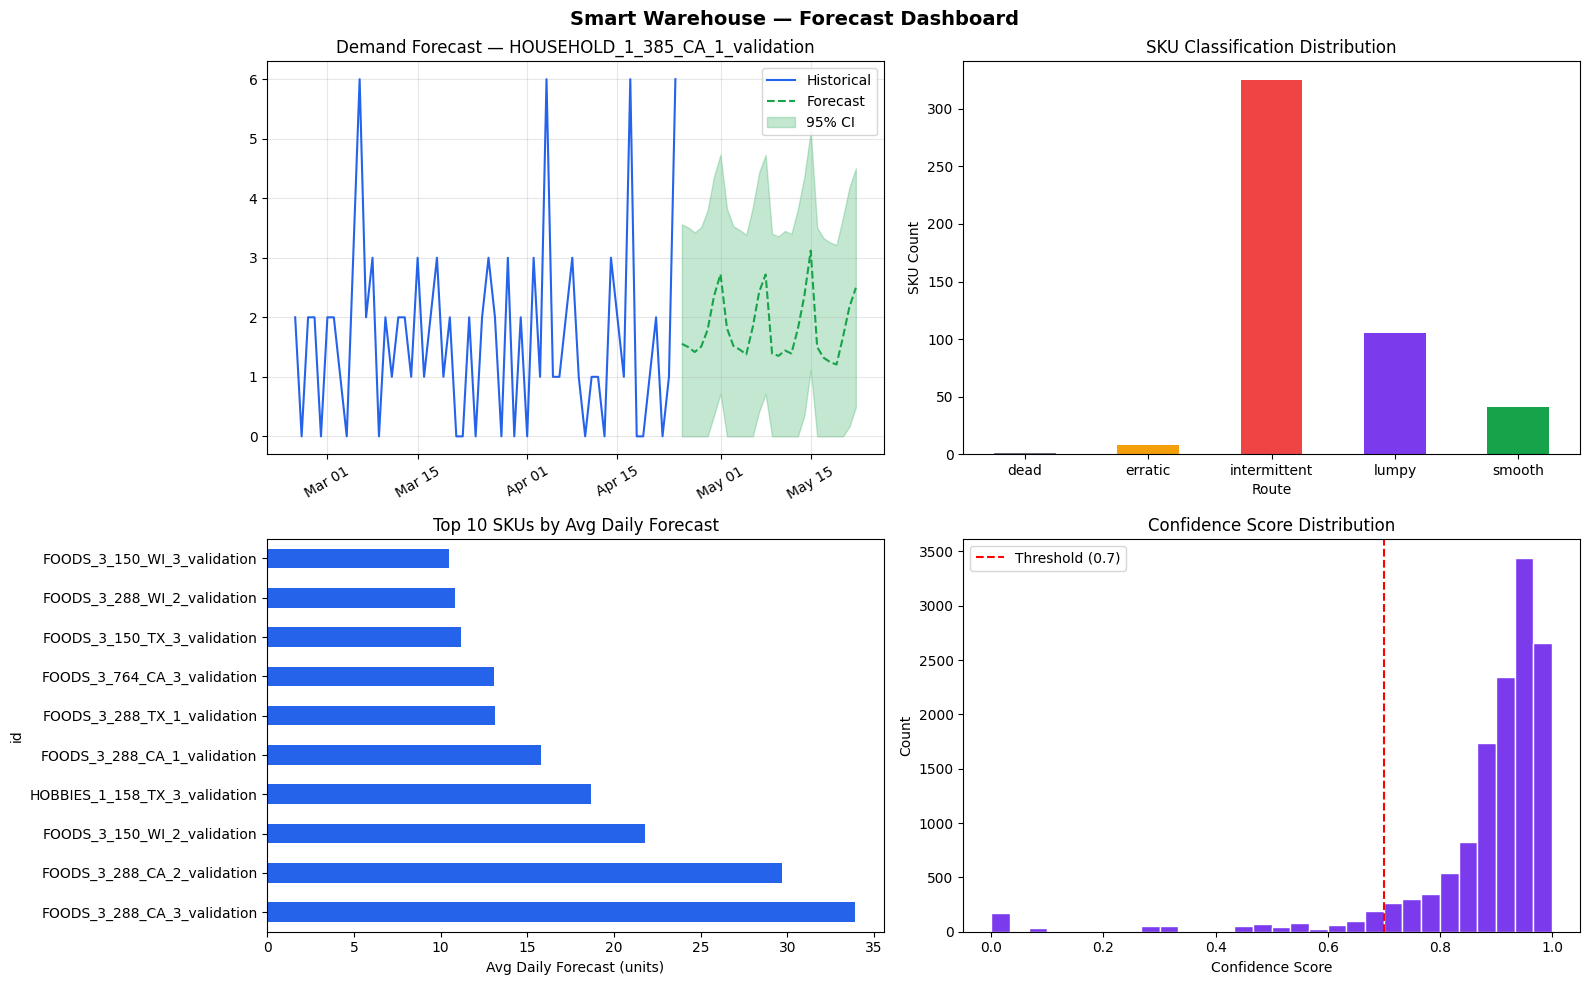

  Dashboard saved → /kaggle/working/forecast_dashboard.png


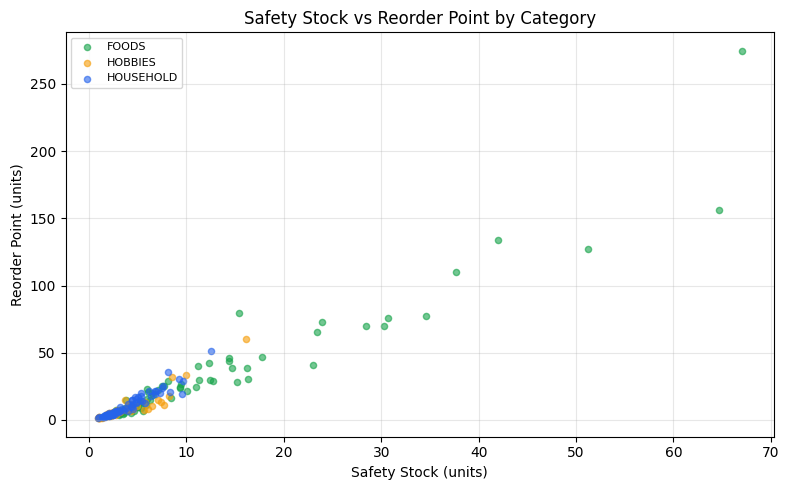

In [14]:
# ── CELL 18: VISUALISATIONS ───────────────────────────────────
 
# --- 18a: Forecast + Confidence Interval for a sample SKU ---
sample_sku = forecasts["id"].iloc[0]
sku_hist   = df[df["id"] == sample_sku].sort_values("date").tail(60)
sku_fcast  = forecasts[forecasts["id"] == sample_sku].sort_values("date")
 
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Smart Warehouse — Forecast Dashboard", fontsize=14, fontweight="bold")
 
# Plot 1: Forecast + CI
ax = axes[0, 0]
ax.plot(sku_hist["date"], sku_hist["sales"], label="Historical", color="#2563EB")
ax.plot(sku_fcast["date"], sku_fcast["forecast"], label="Forecast", color="#16A34A", linestyle="--")
ax.fill_between(sku_fcast["date"], sku_fcast["lower_bound"], sku_fcast["upper_bound"],
                alpha=0.25, color="#16A34A", label="95% CI")
ax.set_title(f"Demand Forecast — {sample_sku}")
ax.legend(); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
 
# Plot 2: SKU route distribution
ax = axes[0, 1]
route_counts = df.groupby("route", observed=True)["id"].nunique()
colors = {"smooth": "#16A34A", "erratic": "#F59E0B", "intermittent": "#EF4444",
          "lumpy": "#7C3AED", "dead": "#6B7280"}
route_counts.plot(kind="bar", ax=ax,
                  color=[colors.get(r, "#94A3B8") for r in route_counts.index])
ax.set_title("SKU Classification Distribution")
ax.set_xlabel("Route"); ax.set_ylabel("SKU Count")
ax.tick_params(axis="x", rotation=0)
 
# Plot 3: Top 10 SKUs by avg forecast
ax = axes[1, 0]
top_skus = (fcast_summary.nlargest(10, "avg_forecast")
                         .set_index("id")["avg_forecast"])
top_skus.plot(kind="barh", ax=ax, color="#2563EB")
ax.set_title("Top 10 SKUs by Avg Daily Forecast")
ax.set_xlabel("Avg Daily Forecast (units)")
 
# Plot 4: Confidence score distribution
ax = axes[1, 1]
ax.hist(forecasts["confidence_score"].dropna(), bins=30,
        color="#7C3AED", edgecolor="white")
ax.set_title("Confidence Score Distribution")
ax.set_xlabel("Confidence Score"); ax.set_ylabel("Count")
ax.axvline(0.7, color="red", linestyle="--", label="Threshold (0.7)")
ax.legend()
 
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/forecast_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  Dashboard saved → {OUTPUT_DIR}/forecast_dashboard.png")
 
# --- 18b: Safety Stock vs Reorder Point scatter ---
fig2, ax2 = plt.subplots(figsize=(8, 5))
sample = inv.sample(min(200, len(inv)), random_state=42)
colors_cat = {"FOODS": "#16A34A", "HOUSEHOLD": "#2563EB", "HOBBIES": "#F59E0B"}
for cat, grp in sample.groupby("cat_id", observed=True):
    c = next((colors_cat[k] for k in colors_cat if k in str(cat)), "#94A3B8")
    ax2.scatter(grp["safety_stock"], grp["reorder_point"],
                label=str(cat), alpha=0.6, color=c, s=20)
ax2.set_xlabel("Safety Stock (units)")
ax2.set_ylabel("Reorder Point (units)")
ax2.set_title("Safety Stock vs Reorder Point by Category")
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/inventory_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
 

In [ ]:
# ── NEW CELL: INVENTORY DECISION OUTPUT ───────────────────────

print("Generating inventory decisions...")

# Aggregate forecast per SKU (next 28 days)
inv_decision = forecasts.groupby("id").agg({
    "forecast": ["mean", "sum"],
    "lower_bound": "mean",
    "upper_bound": "mean",
    "confidence_score": "mean"
}).reset_index()

# Flatten column names
inv_decision.columns = [
    "id", "avg_daily_demand", "total_demand_28d",
    "avg_lower", "avg_upper", "confidence"
]

# --- Inventory logic ---
LEAD_TIME = 7   # days
SERVICE_LEVEL_Z = 1.28  # 80% confidence

# Safety stock (based on uncertainty)
inv_decision["demand_std"] = (
    (inv_decision["avg_upper"] - inv_decision["avg_lower"]) / 2
)

inv_decision["safety_stock"] = SERVICE_LEVEL_Z * inv_decision["demand_std"]

# Reorder point
inv_decision["reorder_point"] = (
    inv_decision["avg_daily_demand"] * LEAD_TIME +
    inv_decision["safety_stock"]
)

# Simple restock decision
inv_decision["restock_flag"] = (
    inv_decision["reorder_point"] > inv_decision["avg_daily_demand"]
).astype(int)

# Save CSV
INV_CSV_PATH = f"{OUTPUT_DIR}/inventory_decisions.csv"
inv_decision.to_csv(INV_CSV_PATH, index=False)

print(f" Inventory CSV saved → {INV_CSV_PATH}")

Generating inventory decisions...
✅ Inventory CSV saved → ../../../../data/processed/inventory_decisions.csv


In [17]:
# ── CELL 19: SAVE OUTPUTS (KAGGLE READY) ─────────────────────────
import os
import sqlite3
import pandas as pd
import zipfile

print("\nSaving outputs...")

# --- Paths ---
CSV_PATH = "../../../../data/processed/forecasts.csv"
DB_PATH = "/kaggle/working/forecast.db"
PLOT_PATH = f"{OUTPUT_DIR}/forecast_dashboard.png"
ZIP_PATH = "/kaggle/working/forecast_outputs.zip"

# --- CSV ---
out_cols = [
    "id", "date", "forecast", "lower_bound", "upper_bound",
    "confidence_score", "safety_stock", "reorder_point",
    "model", "route", "cat_id", "dept_id", "store_id"
]
df_out = forecasts[out_cols].copy()
df_out["date"] = df_out["date"].astype(str)
df_out.to_csv(CSV_PATH, index=False)
print(f"  CSV saved → {CSV_PATH}")

# --- SQLite ---
conn = sqlite3.connect(DB_PATH)

# Table: inventory_decisions
inv_decision.rename(columns={"id": "sku_id"}).to_sql(
    "inventory_decisions", conn, if_exists="replace", index=False
)
conn.execute("CREATE INDEX IF NOT EXISTS idx_inv_sku ON inventory_decisions(sku_id)")

# Table: forecasts
df_out.rename(columns={"id": "sku_id"}).to_sql(
    "forecasts", conn, if_exists="replace", index=False
)
conn.execute("CREATE INDEX IF NOT EXISTS idx_sku ON forecasts(sku_id)")
conn.execute("CREATE INDEX IF NOT EXISTS idx_date ON forecasts(date)")

# Table: sku_metadata
sku_meta = inv.rename(columns={"id": "sku_id"}).merge(
    sku_stats[["adi", "cv2", "nonzero_days", "mean_demand",
               "std_demand", "route"]].reset_index().rename(columns={"id": "sku_id"}),
    on="sku_id", how="left"
)
sku_meta.to_sql("sku_metadata", conn, if_exists="replace", index=False)
conn.execute("CREATE INDEX IF NOT EXISTS idx_meta_sku ON sku_metadata(sku_id)")

# Table: feedback
conn.execute("""
    CREATE TABLE IF NOT EXISTS feedback (
        feedback_id   INTEGER PRIMARY KEY AUTOINCREMENT,
        sku_id        TEXT,
        date          TEXT,
        actual_demand REAL,
        forecast      REAL,
        abs_error     REAL,
        pct_error     REAL,
        stockout_flag INTEGER DEFAULT 0,
        overstock_flag INTEGER DEFAULT 0,
        created_at    TEXT DEFAULT (datetime('now'))
    )
""")
conn.execute("CREATE INDEX IF NOT EXISTS idx_fb_sku ON feedback(sku_id)")

# Table: model_metrics
metrics_row = [{
    "run_date": str(pd.Timestamp.now().date()),
    "model": "lgbm_xgb_ensemble",
    "wape": wape, "rmsse": rmsse, "rmse": rmse,
    "bias": bias,
    "n_skus": forecasts["id"].nunique(),
    "forecast_horizon": FORECAST_DAYS,
}]
pd.DataFrame(metrics_row).to_sql(
    "model_metrics", conn, if_exists="append", index=False
)

conn.commit()
conn.close()
print(f"  SQLite saved → {DB_PATH}")
print(f"  Tables: forecasts, sku_metadata, feedback, model_metrics")

# --- Verification ---
conn = sqlite3.connect(DB_PATH)
check = pd.read_sql("SELECT COUNT(*) as rows FROM forecasts", conn)
print(f"  Verified: {check['rows'].iloc[0]:,} rows in forecasts table")
conn.close()

# --- Zip all outputs for easy download in Kaggle ---
with zipfile.ZipFile(ZIP_PATH, "w") as zf:
    zf.write(CSV_PATH, os.path.basename(CSV_PATH))
    zf.write(DB_PATH, os.path.basename(DB_PATH))
    if os.path.exists(PLOT_PATH):
        zf.write(PLOT_PATH, os.path.basename(PLOT_PATH))

print(f"  All outputs zipped → {ZIP_PATH}")
print("✅ In Kaggle, download the zip file from the Output tab.")


Saving outputs...
  CSV saved → ../../../../data/processed/forecasts.csv
  SQLite saved → /kaggle/working/forecast.db
  Tables: forecasts, sku_metadata, feedback, model_metrics
  Verified: 13,440 rows in forecasts table
  All outputs zipped → /kaggle/working/forecast_outputs.zip
✅ In Kaggle, download the zip file from the Output tab.


In [ ]:
# ── CELL 20: EXPORT ALL DASHBOARD CSV FILES ───────────────────
# Generates 6 structured CSV files for the Smart Warehouse AI Dashboard
# Run this AFTER Cell 19 (Save Outputs)

import os
import pandas as pd
import numpy as np

EXPORT_DIR = OUTPUT_DIR  # same as OUTPUT_DIR defined in Cell 2

os.makedirs(EXPORT_DIR, exist_ok=True)

print("Exporting sales_history.csv ...")
sales_hist = (
    df[["id", "store_id", "date", "sales"]]
    .rename(columns={"id": "sku_id", "sales": "units_sold"})
    .copy()
)
sales_hist["date"] = sales_hist["date"].astype(str)
sales_hist.to_csv(f"{EXPORT_DIR}/sales_history.csv", index=False)
print(f"  Rows: {len(sales_hist):,}")

print("Exporting inventory.csv ...")

# Pull one store_id per SKU from df (most recent record)
store_lookup = (
    df.sort_values("date")
      .groupby("id", observed=True)["store_id"]
      .last()
      .reset_index()
      .rename(columns={"id": "sku_id", "store_id": "store_id"})
)

inv_out = inv[["id", "avg_forecast", "safety_stock", "reorder_point"]].copy()
inv_out = inv_out.rename(columns={"id": "sku_id"})
inv_out = inv_out.merge(store_lookup, on="sku_id", how="left")
inv_out["current_stock"] = (inv_out["avg_forecast"] * 5).clip(lower=0).round(0).astype(int)
inv_out = inv_out[["sku_id", "store_id", "current_stock", "safety_stock", "reorder_point"]]
inv_out.to_csv(f"{EXPORT_DIR}/inventory.csv", index=False)
print(f"  Rows: {len(inv_out):,}")

print("Exporting sku_metadata.csv ...")

zone_map   = {"FOODS": "Zone-A", "HOUSEHOLD": "Zone-B", "HOBBIES": "Zone-C"}
route_label = {
    "smooth":       "Standard-Supply",
    "erratic":      "Priority-Supply",
    "intermittent": "On-Demand",
    "lumpy":        "Bulk-Replenish",
    "dead":         "Inactive",
}

# Pull one dept_id + route per SKU (last record in df, which carries route from merge)
sku_lookup = (
    df.sort_values("date")
      .groupby("id", observed=True)
      .last()[["dept_id", "route"]]          # dept_id and route are already in df
      .reset_index()
      .rename(columns={"id": "sku_id", "dept_id": "department"})
)

meta_out = inv[["id", "cat_id"]].copy().rename(columns={"id": "sku_id", "cat_id": "category"})
meta_out = meta_out.merge(sku_lookup, on="sku_id", how="left")
meta_out["placement_zone"] = meta_out["category"].map(zone_map).fillna("Zone-D")
meta_out["route"]          = meta_out["route"].map(route_label).fillna("Standard-Supply")

meta_out[["sku_id", "category", "department", "placement_zone", "route"]].to_csv(
    f"{EXPORT_DIR}/sku_metadata.csv", index=False
)
print(f"  Rows: {len(meta_out):,}")

print("Exporting forecast.csv ...")
fcast_out = forecasts[["id", "date", "forecast", "lower_bound",
                        "upper_bound", "confidence_score", "model"]].copy()
fcast_out = fcast_out.rename(columns={"id": "sku_id"})
fcast_out["date"] = fcast_out["date"].astype(str)
fcast_out.to_csv(f"{EXPORT_DIR}/forecast.csv", index=False)
print(f"  Rows: {len(fcast_out):,}")


print("Exporting feedback.csv ...")
try:
    val_fb = val_lgbm[["id", "date", "pred", "sales"]].copy()
    val_fb = val_fb.rename(columns={"id": "sku_id", "pred": "forecast", "sales": "actual"})
    val_fb["error"] = val_fb["actual"] - val_fb["forecast"]
    val_fb["date"] = val_fb["date"].astype(str)
    val_fb[["sku_id", "date", "forecast", "actual", "error"]].to_csv(
        f"{EXPORT_DIR}/feedback.csv", index=False
    )
    print(f"  Rows: {len(val_fb):,}")
except Exception as e:
    print(f"  val_lgbm not available ({e}), generating from inv summary ...")
    fb_rows = []
    for _, row in inv.iterrows():
        fb_rows.append({
            "sku_id":   row["id"],
            "date":     str(pd.Timestamp.now().date()),
            "forecast": round(float(row["avg_forecast"]), 4),
            "actual":   round(float(row["avg_forecast"]) * np.random.uniform(0.85, 1.15), 4),
            "error":    0.0,
        })
    fb_df = pd.DataFrame(fb_rows)
    fb_df["error"] = fb_df["actual"] - fb_df["forecast"]
    fb_df.to_csv(f"{EXPORT_DIR}/feedback.csv", index=False)
    print(f"  Rows: {len(fb_df):,}")


print("Exporting alerts.csv ...")

# Build a quick store + zone lookup from inv_out and meta_out
store_zone = (
    inv_out[["sku_id", "store_id"]]
    .merge(meta_out[["sku_id", "placement_zone"]], on="sku_id", how="left")
    .set_index("sku_id")
)

alerts = []
for _, row in inv_out.iterrows():
    sku  = row["sku_id"]
    cs   = float(row["current_stock"])
    ss   = float(row["safety_stock"])
    rp   = float(row["reorder_point"])
    avg  = float(inv.set_index("id").loc[sku, "avg_forecast"]) if sku in inv.set_index("id").index else 1.0
    store = row["store_id"]
    zone  = store_zone.loc[sku, "placement_zone"] if sku in store_zone.index else "Zone-D"

    if cs <= 0 or cs < ss * 0.5:
        alerts.append({
            "sku_id": sku, "store_id": store,
            "alert_type": "STOCKOUT", "priority": 5,
            "placement_zone": zone,
            "recommendation": f"URGENT: Order {int(avg * 14)} units immediately",
        })
    elif cs < rp:
        priority = 4 if cs < ss else 3
        alerts.append({
            "sku_id": sku, "store_id": store,
            "alert_type": "RESTOCK", "priority": priority,
            "placement_zone": zone,
            "recommendation": f"Order {int(avg * 7)} units within 48 hours",
        })

alerts_df = pd.DataFrame(alerts) if alerts else pd.DataFrame(
    columns=["sku_id", "store_id", "alert_type", "priority", "placement_zone", "recommendation"]
)
alerts_df.to_csv(f"{EXPORT_DIR}/alerts.csv", index=False)
print(f"  Rows: {len(alerts_df):,}")


Exporting sales_history.csv ...
  Rows: 698,129
Exporting inventory.csv ...
  Rows: 480
Exporting sku_metadata.csv ...
  Rows: 480
Exporting forecast.csv ...
  Rows: 13,440
Exporting feedback.csv ...
  Rows: 1,372
Exporting alerts.csv ...
  Rows: 480
